# The aim of this project is to develop a deep learning model that can analyse chest X-ray images and identify possible medical conditions.



In [1]:
# Data Processing Libraries
import numpy as np
import pandas as pd
import os
# Image Processing Libraries
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score, hamming_loss)

In [2]:
# Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print(f"TensorFlow version: {tf.__version__}")

2026-08-28 00:11:48.401299: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787875908.423762     668 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787875908.431135     668 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787875908.449148     668 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787875908.449166     668 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787875908.449169     668 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [4]:
# Set Dataset Path
dataset_path = "/kaggle/input/datasets/katlegomashala/chest-xray/Dataset"

In [5]:
# Load CSV
df = pd.read_csv(f"{dataset_path}/Data_Entry_2017_v2020.csv")

df.head(10)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168
5,00000003_002.png,Hernia,1,3,75,F,PA,2048,2500,0.168,0.168
6,00000003_003.png,Hernia|Infiltration,2,3,76,F,PA,2698,2991,0.143,0.143
7,00000003_004.png,Hernia,3,3,77,F,PA,2500,2048,0.168,0.168
8,00000003_005.png,Hernia,4,3,78,F,PA,2686,2991,0.143,0.143
9,00000003_006.png,Hernia,5,3,79,F,PA,2992,2991,0.143,0.143


In [6]:
# Keep Required Columns
df = df[['Image Index', 'Finding Labels']]
df

,Image Index,Finding Labels
0,00000001_000.png,Cardiomegaly
1,00000001_001.png,Cardiomegaly|Emphysema
2,00000001_002.png,Cardiomegaly|Effusion
3,00000002_000.png,No Finding
4,00000003_001.png,Hernia
...,...,...
112115,00030801_001.png,Mass|Pneumonia
112116,00030802_000.png,No Finding
112117,00030803_000.png,No Finding
112118,00030804_000.png,No Finding


In [7]:
# Convert "No finding" into Normal, if no desease found the patient is normal
df['Finding Labels'] = df['Finding Labels'].replace('No Finding', 'Normal')

print(f"Total records in CSV: {len(df)}")
df.head(10)

Total records in CSV: 112120


,Image Index,Finding Labels
0,00000001_000.png,Cardiomegaly
1,00000001_001.png,Cardiomegaly|Emphysema
2,00000001_002.png,Cardiomegaly|Effusion
3,00000002_000.png,Normal
4,00000003_001.png,Hernia
5,00000003_002.png,Hernia
6,00000003_003.png,Hernia|Infiltration
7,00000003_004.png,Hernia
8,00000003_005.png,Hernia
9,00000003_006.png,Hernia


In [8]:
# Define all Classes
classes = [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural_Thickening",
    "Hernia",
    "Normal"
    ]
print(f"\nTotal classes: {len(classes)}")


Total classes: 15


In [9]:
# Create a Label Map
label_map = {label: i for i, label in enumerate(classes)}
label_map

{'Atelectasis': 0,
 'Cardiomegaly': 1,
 'Effusion': 2,
 'Infiltration': 3,
 'Mass': 4,
 'Nodule': 5,
 'Pneumonia': 6,
 'Pneumothorax': 7,
 'Consolidation': 8,
 'Edema': 9,
 'Emphysema': 10,
 'Fibrosis': 11,
 'Pleural_Thickening': 12,
 'Hernia': 13,
 'Normal': 14}

In [10]:
# Count class occurrences in full dataset
label_counts = {cls: 0 for cls in classes}
for labels in df['Finding Labels']:
    for l in labels.split('|'):
        if l in label_counts:
            label_counts[l] += 1

print("\nClass Distribution in Full Dataset:")
for cls, count in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f"  {cls:25s}: {count}")


Class Distribution in Full Dataset:
  Normal                   : 60361
  Infiltration             : 19894
  Effusion                 : 13317
  Atelectasis              : 11559
  Nodule                   : 6331
  Mass                     : 5782
  Pneumothorax             : 5302
  Consolidation            : 4667
  Pleural_Thickening       : 3385
  Cardiomegaly             : 2776
  Emphysema                : 2516
  Edema                    : 2303
  Fibrosis                 : 1686
  Pneumonia                : 1431
  Hernia                   : 227


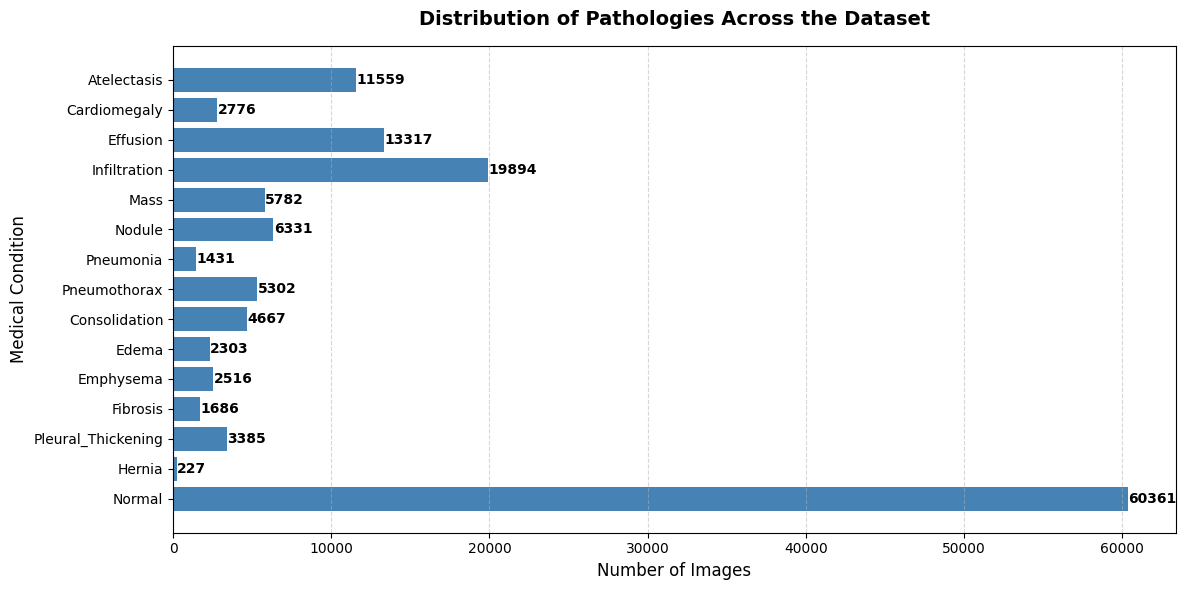

In [11]:
# Plot class distribution
plt.figure(figsize=(12, 6))

bars = plt.barh(
    list(label_counts.keys()),
    list(label_counts.values()),
    color='steelblue'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 30,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center',
        ha='left',
        fontsize=10,
        weight='bold'
    )
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Medical Condition', fontsize=12)
plt.title('Distribution of Pathologies Across the Dataset', fontsize=14, weight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [12]:
# Multi-Label Encoding
def encode_labels(label_string):
    """Convert label string to 15-dimensional binary vector."""
    vector = np.zeros(len(classes))
    for label in label_string.split('|'):
        if label in label_map:
            vector[label_map[label]] = 1
    return vector

df['encoded_labels'] = df['Finding Labels'].apply(encode_labels)

pd.set_option('display.max_colwidth', 80)
df.head()

,Image Index,Finding Labels,encoded_labels
0,00000001_000.png,Cardiomegaly,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,00000001_001.png,Cardiomegaly|Emphysema,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]"
2,00000001_002.png,Cardiomegaly|Effusion,"[0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
3,00000002_000.png,Normal,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
4,00000003_001.png,Hernia,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"


In [13]:
# Define Image Folders
image_folders = [
    f"{dataset_path}/images_001",
    f"{dataset_path}/images_002",
    f"{dataset_path}/images_003",
#    f"{dataset_path}/images_004", Not used
#    f"{dataset_path}/images_005", Not used
#    f"{dataset_path}/images_006", Not used
#    f"{dataset_path}/images_007", Not used
#    f"{dataset_path}/images_008", Not used
#    f"{dataset_path}/images_009", Not used
#    f"{dataset_path}/images_010", Not used
#    f"{dataset_path}/images_011", Not used
#    f"{dataset_path}/images_012", Not used
]

# Find Image Path
def find_image_paths(image_name):
  for folder in image_folders:
    path = os.path.join(folder, image_name)
    if os.path.exists(path):
      return path
  return None

# Path Search
df['image_path'] = df['Image Index'].apply(find_image_paths)
df = df[df['image_path'].notnull()]
print(f"\nImages found on disk: {len(df)}")


Images found on disk: 24999


In [14]:
# Check Available Class Distribution on disk
print("\nActual class distribution on disk:")
actual_counts = {}
for i, cls in enumerate(classes):
    count = int(df['encoded_labels'].apply(lambda x: x[i]).sum())
    actual_counts[cls] = count
    print(f"  {cls:25s}: {count}")


Actual class distribution on disk:
  Atelectasis              : 2270
  Cardiomegaly             : 820
  Effusion                 : 2332
  Infiltration             : 3714
  Mass                     : 846
  Nodule                   : 1221
  Pneumonia                : 288
  Pneumothorax             : 951
  Consolidation            : 916
  Edema                    : 349
  Emphysema                : 476
  Fibrosis                 : 554
  Pleural_Thickening       : 741
  Hernia                   : 59
  Normal                   : 14597


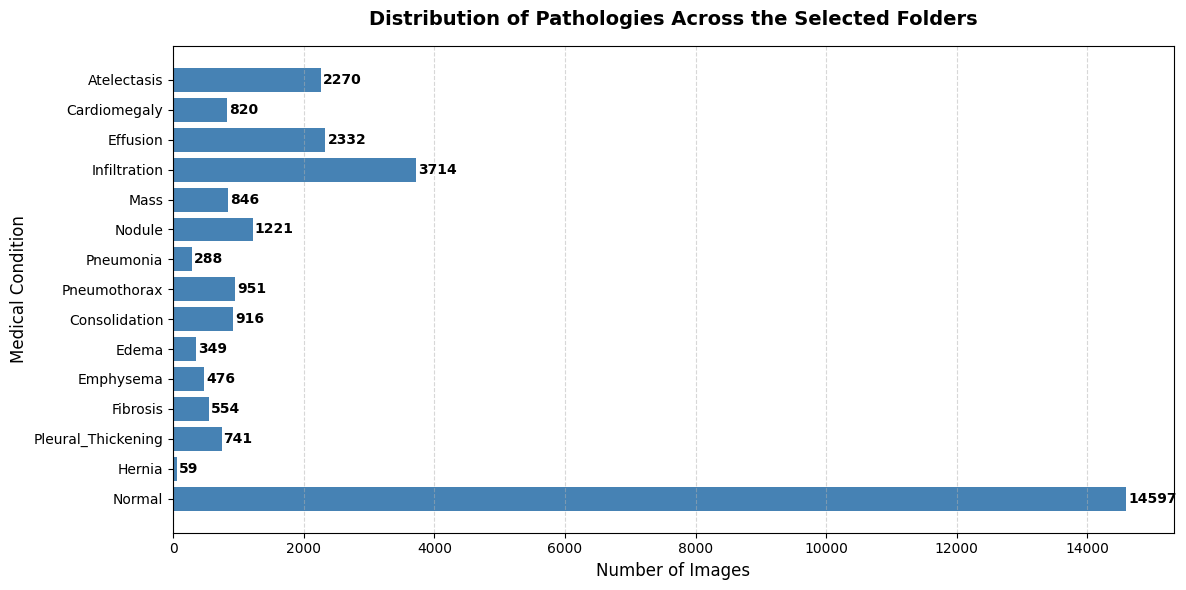

In [15]:
# Plot actual class distribution on disk
plt.figure(figsize=(12, 6))

bars = plt.barh(
    list(actual_counts.keys()),
    list(actual_counts.values()),
    color='steelblue'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 30,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center',
        ha='left',
        fontsize=10,
        weight='bold'
    )

plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Medical Condition', fontsize=12)
plt.title('Distribution of Pathologies Across the Selected Folders', fontsize=14, weight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('actual_class_distribution.png', dpi=150)
plt.show()


In [16]:
# Balance Sampling
# Why balanced sampling?
# Random sampling would give Normal ~14597 images but Hernia only ~59.
# The model would learn to predict Normal for everything.
# Solution: cap each class at 300 samples so all classes are represented.

samples_per_class = 300

sampled_indices = []
print("\nSampling per class:")
for i, cls in enumerate(classes):
    cls_indices = df[
        df['encoded_labels'].apply(lambda x: x[i] == 1)
    ].index.tolist()

    available = len(cls_indices)
    n = min(available, samples_per_class)
    sampled = pd.Series(cls_indices).sample(n, random_state=42).tolist()
    sampled_indices.extend(sampled)
    print(f"  {cls:25s}: {available:4d} available  →  took {n}")

# Remove duplicates from multi-label images
sampled_indices = list(set(sampled_indices))
df_sample = df.loc[sampled_indices].reset_index(drop=True)

print(f"\nTotal unique samples after balanced sampling: {len(df_sample)}")


Sampling per class:
  Atelectasis              : 2270 available  →  took 300
  Cardiomegaly             :  820 available  →  took 300
  Effusion                 : 2332 available  →  took 300
  Infiltration             : 3714 available  →  took 300
  Mass                     :  846 available  →  took 300
  Nodule                   : 1221 available  →  took 300
  Pneumonia                :  288 available  →  took 288
  Pneumothorax             :  951 available  →  took 300
  Consolidation            :  916 available  →  took 300
  Edema                    :  349 available  →  took 300
  Emphysema                :  476 available  →  took 300
  Fibrosis                 :  554 available  →  took 300
  Pleural_Thickening       :  741 available  →  took 300
  Hernia                   :   59 available  →  took 59
  Normal                   : 14597 available  →  took 300

Total unique samples after balanced sampling: 3844


In [17]:
# Calculating Per-Class Loss Weight Penalties
labels_matrix = np.array(df_sample['encoded_labels'].tolist())
total_samples = labels_matrix.shape[0]
pos_counts = labels_matrix.sum(axis=0)
neg_counts = total_samples - pos_counts
pos_counts = np.maximum(pos_counts, 1) 

derived_pos_weights = neg_counts / pos_counts
 
print("CALCULATED PER-CLASS LOSS WEIGHT PENALTIES:\n")
for i, cls in enumerate(classes):
    print(f"{cls:25s} -> Multiplier: {derived_pos_weights[i]:.2f}x")

CALCULATED PER-CLASS LOSS WEIGHT PENALTIES:

Atelectasis               -> Multiplier: 4.43x
Cardiomegaly              -> Multiplier: 8.68x
Effusion                  -> Multiplier: 3.87x
Infiltration              -> Multiplier: 2.89x
Mass                      -> Multiplier: 8.31x
Nodule                    -> Multiplier: 7.16x
Pneumonia                 -> Multiplier: 12.35x
Pneumothorax              -> Multiplier: 7.62x
Consolidation             -> Multiplier: 7.84x
Edema                     -> Multiplier: 11.05x
Emphysema                 -> Multiplier: 10.37x
Fibrosis                  -> Multiplier: 10.54x
Pleural_Thickening        -> Multiplier: 8.51x
Hernia                    -> Multiplier: 64.15x
Normal                    -> Multiplier: 11.81x


In [18]:
class WeightedBinaryCrossEntropy(tf.keras.losses.Loss):
    def __init__(self, pos_weights, name="weighted_binary_crossentropy"):
        super().__init__(name=name)
        self.pos_weights = tf.constant(pos_weights, dtype=tf.float32)
 
    def call(self, y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
 
        pos_loss = y_true * tf.math.log(y_pred) * self.pos_weights
        neg_loss = (1.0 - y_true) * tf.math.log(1.0 - y_pred)
        return -tf.reduce_mean(pos_loss + neg_loss, axis=-1)
 
    def get_config(self):
        config = super().get_config()
        config.update({'pos_weights': self.pos_weights.numpy().tolist()})
        return config
 
print("WeightedBinaryCrossEntropy loss class defined successfully.")

WeightedBinaryCrossEntropy loss class defined successfully.


In [20]:
# Sample Data
#df_sample = df.sample(5500, random_state=42).reset_index(drop=True)

In [21]:
#Load and Preprocess images
def load_image(path):
  """Load image, resize to 224x224, normalise pixels to [0, 1]."""
  img = cv2.imread(path)
  img = cv2.resize(img, (224, 224))
  img = img.astype(np.float32) / 255.0
  return img

X = []
y = []

for i in range(len(df_sample)):
  img = load_image(df_sample.iloc[i]['image_path'])
  label = df_sample.iloc[i]['encoded_labels']
  X.append(img)
  y.append(label)

X = np.array(X)
y = np.array(y)

print(f"X shape: {X.shape}")     # (samples, 224, 224, 3)
print(f"y shape: {y.shape}")     # (samples, 15)
print(f"Pixel range: [{X.min():.2f}, {X.max():.2f}]")
print(f"Number of classes: {y.shape[1]}")

X shape: (3844, 224, 224, 3)
y shape: (3844, 15)
Pixel range: [0.00, 1.00]
Number of classes: 15


In [22]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")


Training samples : 3075
Test samples     : 769


# **Building a Deep Learning Model using Transfer Learning**

In [23]:
tf.keras.backend.clear_session()

In [24]:
# Load ResNet50 pretrained on ImageNet (without classification head)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
print(f"\nResNet50 loaded. Total layers: {len(base_model.layers)}")

I0000 00:00:1787876008.415829     668 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



ResNet50 loaded. Total layers: 175


In [25]:
# Set trainable True first, then freeze everything except last 95
base_model.trainable = True
for layer in base_model.layers[:-95]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
total_count = len(base_model.layers)
print(f"\nResNet50 loaded.")
print(f"Total layers in base: {total_count}")
print(f"Active trainable layers inside base: {trainable_count}")


ResNet50 loaded.
Total layers in base: 175
Active trainable layers inside base: 95


In [26]:
# Build the full model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(15, activation='sigmoid', dtype='float32')
    # dtype='float32' on output is required with mixed precision
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,116,111 (92.00 MB)

 Trainable params: 22,613,007 (86.26 MB)

 Non-trainable params: 1,503,104 (5.73 MB)

In [27]:
# Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.000002),  # 2e-6 exactly as in laptop code
    loss=WeightedBinaryCrossEntropy(pos_weights=derived_pos_weights),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
 
print("\nImbalance-aware model compiled successfully.")


Imbalance-aware model compiled successfully.


In [28]:
# Callbacks
callbacks = [
    ModelCheckpoint(
        '/kaggle/working/best_chest_xray_model.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]
 
print("Callbacks configured.")

Callbacks configured.


In [29]:
# Train the Model
print("\nLaunching Deep Training Pass on sampled images...")
print(f"   Unfrozen layers: {trainable_count}")
print(f"   Learning rate: 2e-6")
print(f"   Loss: WeightedBinaryCrossEntropy")
 
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
 
print("\nDeep fine-tuning pass completed successfully!")


Launching Deep Training Pass on sampled images...
   Unfrozen layers: 95
   Learning rate: 2e-6
   Loss: WeightedBinaryCrossEntropy
Epoch 1/15


I0000 00:00:1787876033.629993     736 service.cc:152] XLA service 0x7fb13c002a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787876033.630030     736 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1787876037.306235     736 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/97 ━━━━━━━━━━━━━━━━━━━━ 55:42 35s/step - accuracy: 0.0938 - auc: 0.5874 - loss: 1.1199

I0000 00:00:1787876049.351173     736 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.0853 - auc: 0.5376 - loss: 1.3368
Epoch 1: val_auc improved from -inf to 0.54267, saving model to /kaggle/working/best_chest_xray_model.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 68s 347ms/step - accuracy: 0.0853 - auc: 0.5376 - loss: 1.3367 - val_accuracy: 0.0975 - val_auc: 0.5427 - val_loss: 1.2889 - learning_rate: 2.0000e-06
Epoch 2/15
96/97 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.0894 - auc: 0.5411 - loss: 1.2591
Epoch 2: val_auc improved from 0.54267 to 0.55601, saving model to /kaggle/working/best_chest_xray_model.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 131ms/step - accuracy: 0.0895 - auc: 0.5410 - loss: 1.2591 - val_accuracy: 0.0910 - val_auc: 0.5560 - val_loss: 1.2603 - learning_rate: 2.0000e-06
Epoch 3/15
96/97 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.0952 - auc: 0.5575 - loss: 1.2427
Epoch 3: val_auc improved from 0.55601 to 0.56947, saving model to /kaggle/working/best_chest_xray_model.keras
97/97 ━━━━━━━━━━━━━━━━━━━

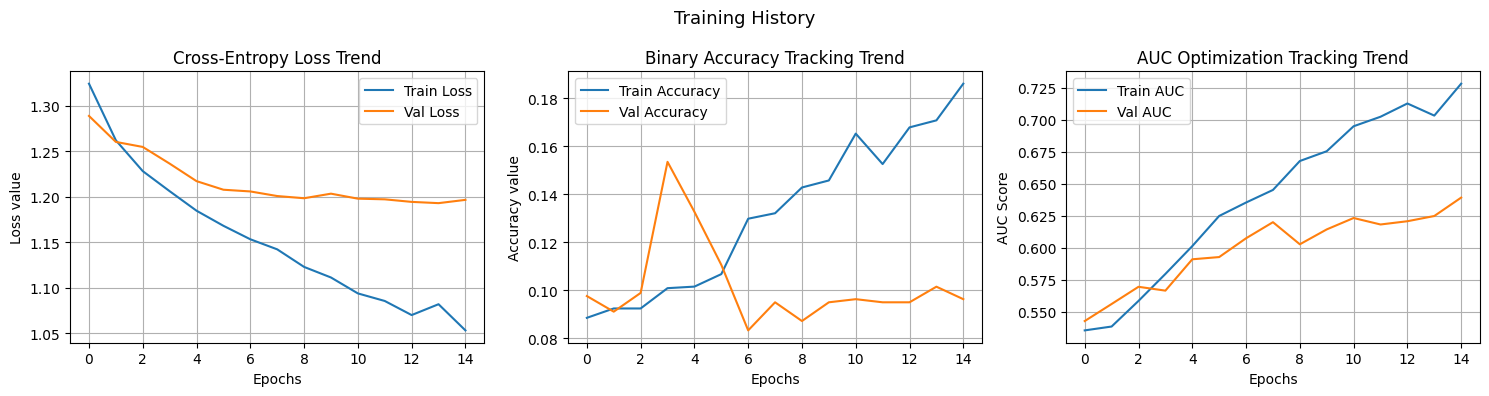

Training history chart saved.


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training History', fontsize=13)
 
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Cross-Entropy Loss Trend')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss value')
axes[0].legend()
axes[0].grid(True)
 
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Binary Accuracy Tracking Trend')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy value')
axes[1].legend()
axes[1].grid(True)
 
axes[2].plot(history.history['auc'], label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('AUC Optimization Tracking Trend')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('AUC Score')
axes[2].legend()
axes[2].grid(True)
 
plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=150)
plt.show()
print("Training history chart saved.")

In [31]:
# Evaluate Model
loss, accuracy, auc = model.evaluate(X_test, y_test, verbose=0)

print("FINAL MODEL EVALUATION")
print(f"Overall Model Validation Loss    : {loss:.4f}")
print(f"Overall Model Validation Accuracy: {accuracy:.4f}")
print(f"Overall Model Validation AUC     : {auc:.4f}")

FINAL MODEL EVALUATION
Overall Model Validation Loss    : 1.1930
Overall Model Validation Accuracy: 0.1014
Overall Model Validation AUC     : 0.6248


In [32]:
# Predictions and Classification
y_pred_probs = model.predict(X_test)
threshold = 0.3
y_pred_binary = (y_pred_probs > threshold).astype(int)
y_true_binary = y_test

print("CLASSIFICATION REPORT (Per Disease Class)")
print(classification_report(
    y_true_binary, y_pred_binary,
    target_names=classes, zero_division=0
))

print("\nOVERALL PERFORMANCE SUMMARY")
exact_acc = accuracy_score(y_true_binary, y_pred_binary)
hamming   = hamming_loss(y_true_binary, y_pred_binary)
precision = precision_score(y_true_binary, y_pred_binary,
                            average='macro', zero_division=0)
recall    = recall_score(y_true_binary, y_pred_binary,
                         average='macro', zero_division=0)
f1        = f1_score(y_true_binary, y_pred_binary,
                     average='macro', zero_division=0)

print(f"Exact Match Accuracy : {exact_acc:.2%}")
print(f"Hamming Loss         : {hamming:.2%}")
print(f"Macro Precision      : {precision:.2%}")
print(f"Macro Recall         : {recall:.2%}")
print(f"Macro F1-Score       : {f1:.2%}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step
CLASSIFICATION REPORT (Per Disease Class)
                    precision    recall  f1-score   support

       Atelectasis       0.18      0.98      0.30       136
      Cardiomegaly       0.11      0.99      0.19        81
          Effusion       0.22      1.00      0.35       164
      Infiltration       0.24      0.99      0.39       186
              Mass       0.12      1.00      0.22        95
            Nodule       0.12      1.00      0.22        94
         Pneumonia       0.08      1.00      0.14        59
      Pneumothorax       0.11      1.00      0.19        81
     Consolidation       0.11      0.99      0.20        81
             Edema       0.10      0.97      0.18        58
         Emphysema       0.09      0.97      0.17        70
          Fibrosis       0.09      1.00      0.17        63
Pleural_Thickening       0.10      0.95      0.19        80
            Hernia       0.02      0.83      0.05        12
            Norm

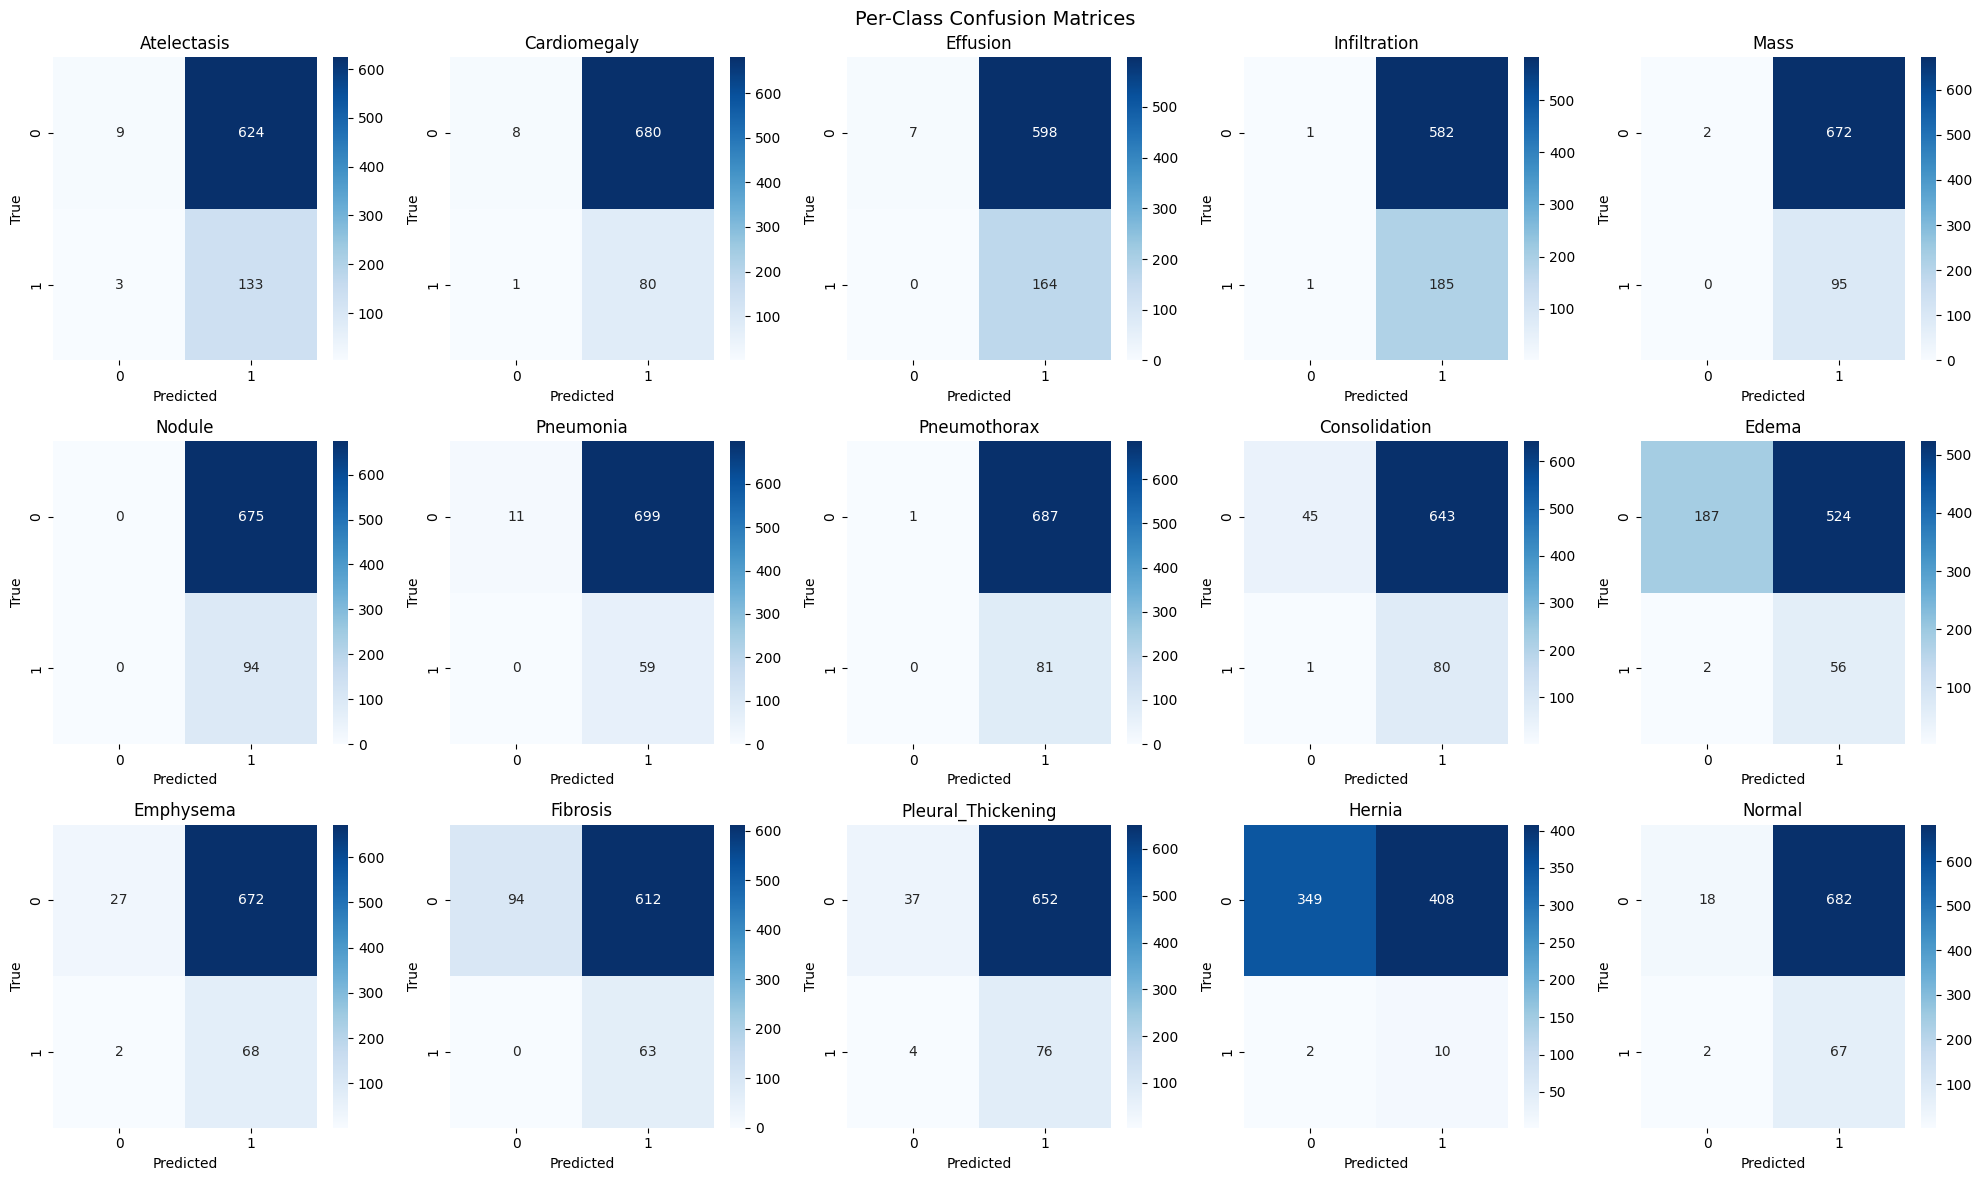

Confusion matrices saved.


In [33]:
# Confusion Matrices (Per Class)
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.ravel()

for i in range(15):
    cm = confusion_matrix(y_true_binary[:, i], y_pred_binary[:, i])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(classes[i])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.suptitle('Per-Class Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("Confusion matrices saved.")

In [34]:
# Saved Model
model.save("/kaggle/working/chest_xray_model.keras")
model.save("/kaggle/working/chest_xray_model.h5")
print("\nModel saved in both .keras and .h5 formats.")


Model saved in both .keras and .h5 formats.


In [35]:
for threshold in [0.4, 0.5, 0.6, 0.7]:
    y_pred_binary = (y_pred_probs > threshold).astype(int)
    precision = precision_score(y_true_binary, y_pred_binary,
                                average='macro', zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary,
                          average='macro', zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary,
                  average='macro', zero_division=0)
    print(f"Threshold {threshold:.1f} → Precision: {precision:.2%}  "
          f"Recall: {recall:.2%}  F1: {f1:.2%}")

Threshold 0.4 → Precision: 12.85%  Recall: 84.55%  F1: 21.95%
Threshold 0.5 → Precision: 15.29%  Recall: 51.46%  F1: 23.10%
Threshold 0.6 → Precision: 18.94%  Recall: 17.11%  F1: 15.73%
Threshold 0.7 → Precision: 10.54%  Recall: 3.41%  F1: 3.93%
